# MCS610 Sprint 2 — AI-Powered Phishing Detection & Awareness Platform

**Sprint 2 implementation:** baseline machine-learning phishing classifier, evaluation, explainability, suspicious URL analysis, and model export.

Dataset expected: the combined phishing email CSV containing:
- `text_combined` — email text
- `label` — `0 = Legitimate`, `1 = Phishing`

This notebook is designed to generate genuine implementation evidence for the Sprint 2 report.

In [ ]:
# If a package is missing, uncomment and run this line once:
# %pip install pandas scikit-learn matplotlib joblib

import os
import re
import glob
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# STEP 1 — Automatically locate the dataset
preferred_names = [
    "phishing_email.csv",
    "Phishing_Email.csv",
    "phishing-email.csv"
]

dataset_path = None

for name in preferred_names:
    if os.path.exists(name):
        dataset_path = name
        break

if dataset_path is None:
    csv_files = glob.glob("*.csv")
    if len(csv_files) == 1:
        dataset_path = csv_files[0]
    elif len(csv_files) > 1:
        # Prefer a CSV that looks like the combined phishing dataset.
        likely = [f for f in csv_files if "phish" in f.lower()]
        dataset_path = likely[0] if likely else csv_files[0]

if dataset_path is None:
    raise FileNotFoundError(
        "Dataset not found. Put phishing_email.csv in the same folder as this notebook."
    )

print("Dataset selected:", dataset_path)

Dataset selected: phishing_email.csv


In [ ]:
# STEP 2 — Load and validate the dataset
df = pd.read_csv(dataset_path)

print("Dataset shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nMissing values:")
print(df.isna().sum())
print("\nFirst 5 rows:")
display(df.head())

required_columns = {"text_combined", "label"}
missing = required_columns - set(df.columns)

if missing:
    raise ValueError(f"Required columns missing: {missing}")

print("\nDataset structure validated successfully.")

Dataset shape: (8260, 2)

Columns: ['text_combined', 'label']

Missing values:
text_combined    0
label            1
dtype: int64

First 5 rows:


,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0.0
1,nom actual vols 24 th forwarded sabrae zajac h...,0.0
2,enron actuals march 30 april 1 201 estimated a...,0.0
3,hpl nom may 30 2001 see attached file hplno 53...,0.0
4,hpl nom june 1 2001 see attached file hplno 60...,0.0



Dataset structure validated successfully.


Rows after cleaning: 8258

Class distribution:
Legitimate (0): 6,900
Phishing   (1): 1,358
Phishing proportion: 16.44%


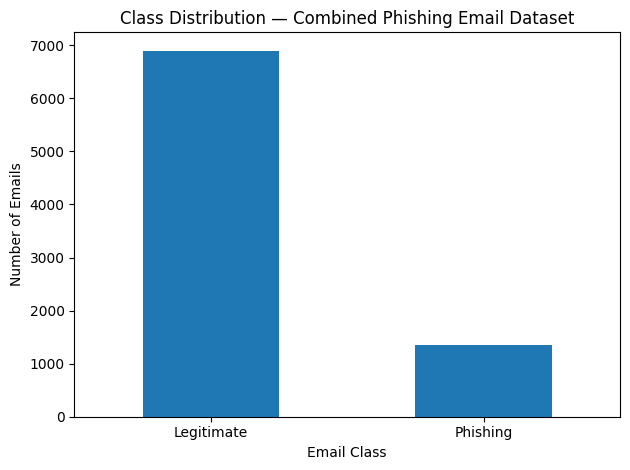

In [ ]:
# STEP 3 — Clean the dataset and inspect class distribution
data = df[["text_combined", "label"]].copy()

data["text_combined"] = data["text_combined"].astype(str).str.strip()
data = data[data["text_combined"].str.len() > 0]
data["label"] = pd.to_numeric(data["label"], errors="coerce")
data = data.dropna(subset=["label"])
data["label"] = data["label"].astype(int)

# Keep only the expected binary classes.
data = data[data["label"].isin([0, 1])].reset_index(drop=True)

label_counts = data["label"].value_counts().sort_index()

print("Rows after cleaning:", len(data))
print("\nClass distribution:")
print(f"Legitimate (0): {label_counts.get(0, 0):,}")
print(f"Phishing   (1): {label_counts.get(1, 0):,}")
print(f"Phishing proportion: {data['label'].mean():.2%}")

ax = label_counts.rename(index={0: "Legitimate", 1: "Phishing"}).plot(
    kind="bar",
    title="Class Distribution — Combined Phishing Email Dataset"
)
ax.set_xlabel("Email Class")
ax.set_ylabel("Number of Emails")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# STEP 4 — Train/test split
X = data["text_combined"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training samples: {len(X_train):,}")
print(f"Testing samples : {len(X_test):,}")
print("\nTraining label distribution:")
print(y_train.value_counts(normalize=True).sort_index())

Training samples: 6,606
Testing samples : 1,652

Training label distribution:
label
0    0.835604
1    0.164396
Name: proportion, dtype: float64


In [ ]:
# STEP 5 — Build and train the baseline ML model
#
# TF-IDF converts email text into weighted numerical features.
# Logistic Regression provides an efficient and interpretable binary classifier.

model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            max_features=20000,
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

print("Training started...")
model.fit(X_train, y_train)
print("Training completed successfully.")

Training started...
Training completed successfully.


In [ ]:
# STEP 6 — Evaluate the trained classifier
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [accuracy, precision, recall, f1]
})

display(results.style.format({"Score": "{:.4f}"}))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Legitimate", "Phishing"],
    digits=4
))

,Metric,Score
0,Accuracy,0.9855
1,Precision,0.9189
2,Recall,1.0000
3,F1-score,0.9577



Classification Report:
              precision    recall  f1-score   support

  Legitimate     1.0000    0.9826    0.9912      1380
    Phishing     0.9189    1.0000    0.9577       272

    accuracy                         0.9855      1652
   macro avg     0.9595    0.9913    0.9745      1652
weighted avg     0.9867    0.9855    0.9857      1652



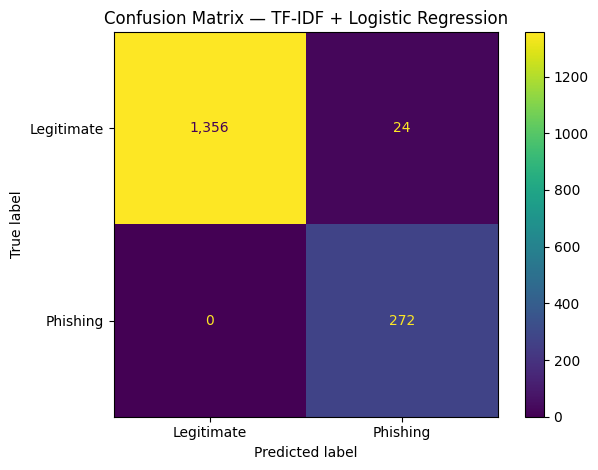

True Negatives : 1,356
False Positives: 24
False Negatives: 0
True Positives : 272


In [ ]:
# STEP 7 — Confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Phishing"]
)

disp.plot(values_format=",d")
plt.title("Confusion Matrix — TF-IDF + Logistic Regression")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives : {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives : {tp:,}")

In [ ]:
# STEP 8 — Explainability: strongest learned indicators
tfidf = model.named_steps["tfidf"]
classifier = model.named_steps["classifier"]

feature_names = np.array(tfidf.get_feature_names_out())
coefficients = classifier.coef_[0]

top_n = 15

top_phishing_idx = np.argsort(coefficients)[-top_n:][::-1]
top_legitimate_idx = np.argsort(coefficients)[:top_n]

top_phishing = pd.DataFrame({
    "Phishing-associated feature": feature_names[top_phishing_idx],
    "Coefficient": coefficients[top_phishing_idx]
})

top_legitimate = pd.DataFrame({
    "Legitimate-associated feature": feature_names[top_legitimate_idx],
    "Coefficient": coefficients[top_legitimate_idx]
})

print("Top learned phishing-associated text features:")
display(top_phishing)

print("Top learned legitimate-associated text features:")
display(top_legitimate)

Top learned phishing-associated text features:


,Phishing-associated feature,Coefficient
0,http,3.804603
1,2004,3.100304
2,money,2.498710
3,click,2.256997
4,online,2.226756
5,paliourg,2.223585
6,mobile,2.205068
7,meds,2.087739
8,low,2.038939
9,remove,1.985271


Top learned legitimate-associated text features:


,Legitimate-associated feature,Coefficient
0,enron,-5.294998
1,vince,-5.005237
2,2000,-3.982472
3,thanks,-3.902843
4,2001,-3.188375
5,attached,-2.924736
6,meter,-2.866024
7,deal,-2.831944
8,gas,-2.734801
9,hpl,-2.651218


In [ ]:
# STEP 9 — Suspicious URL and indicator analysis

URL_PATTERN = re.compile(r'https?://[^\s<>"\\]+|www\.[^\s<>"\\]+', re.IGNORECASE)

SUSPICIOUS_TERMS = [
    "urgent",
    "verify",
    "account suspended",
    "click here",
    "password",
    "login",
    "bank account",
    "confirm your account",
    "security alert",
    "limited time",
    "immediately"
]

def analyse_indicators(email_text):
    text = str(email_text)
    lower_text = text.lower()

    urls = URL_PATTERN.findall(text)
    terms_found = [term for term in SUSPICIOUS_TERMS if term in lower_text]

    suspicious_url_flags = []
    for url in urls:
        url_lower = url.lower()
        flags = []

        if re.search(r'https?://(?:\\d{1,3}\\.){3}\\d{1,3}', url_lower):
            flags.append("IP-address URL")

        if "@" in url:
            flags.append("@ symbol in URL")

        if url_lower.count("-") >= 3:
            flags.append("multiple hyphens")

        if len(url) > 100:
            flags.append("unusually long URL")

        if flags:
            suspicious_url_flags.append({
                "url": url,
                "flags": flags
            })

    return {
        "urls_found": urls,
        "suspicious_terms": terms_found,
        "suspicious_url_flags": suspicious_url_flags
    }

sample_phishing_email = '''
URGENT: Your bank account has been suspended.
Verify your login immediately at http://192.168.10.55/account-login
or your account will be permanently disabled.
'''

indicator_result = analyse_indicators(sample_phishing_email)
indicator_result

{'urls_found': ['http://192.168.10.55/account-login'],
 'suspicious_terms': ['urgent',
  'verify',
  'login',
  'bank account',
  'immediately'],
 'suspicious_url_flags': []}

In [ ]:
# STEP 10 — Integrated phishing-analysis function

def analyse_email(email_text):
    probability = model.predict_proba([email_text])[0]
    predicted_label = int(np.argmax(probability))
    phishing_probability = float(probability[1])

    indicators = analyse_indicators(email_text)

    if phishing_probability >= 0.80:
        risk_level = "HIGH"
    elif phishing_probability >= 0.50:
        risk_level = "MEDIUM"
    else:
        risk_level = "LOW"

    return {
        "prediction": "PHISHING" if predicted_label == 1 else "LEGITIMATE",
        "phishing_probability": round(phishing_probability, 4),
        "risk_level": risk_level,
        "urls_found": indicators["urls_found"],
        "suspicious_terms": indicators["suspicious_terms"],
        "suspicious_url_flags": indicators["suspicious_url_flags"]
    }

test_email = '''
URGENT SECURITY ALERT

Your online banking access has been temporarily suspended.
Verify your account immediately by visiting:
http://192.168.10.55/secure-login

Failure to verify may result in permanent account restriction.
'''

result = analyse_email(test_email)

print("SPRINT 2 PHISHING ANALYSIS RESULT")
print("-" * 45)
for key, value in result.items():
    print(f"{key}: {value}")

SPRINT 2 PHISHING ANALYSIS RESULT
---------------------------------------------
prediction: PHISHING
phishing_probability: 0.8377
risk_level: HIGH
urls_found: ['http://192.168.10.55/secure-login']
suspicious_terms: ['urgent', 'verify', 'login', 'security alert', 'immediately']
suspicious_url_flags: []


In [ ]:
# STEP 11 — Compare a likely legitimate message with a phishing-style message

examples = {
    "Likely legitimate": '''
        Hi team,
        The project meeting is scheduled for Tuesday at 10:00 AM.
        Please review the attached project notes before the meeting.
        Regards,
        Project Coordinator
    ''',
    "Phishing-style": '''
        URGENT! Your bank account has been suspended.
        Verify your password immediately at http://192.168.10.55/account-login
        to prevent permanent account closure.
    '''
}

comparison_rows = []

for name, text in examples.items():
    r = analyse_email(text)
    comparison_rows.append({
        "Example": name,
        "Prediction": r["prediction"],
        "Phishing Probability": r["phishing_probability"],
        "Risk Level": r["risk_level"],
        "Suspicious Terms": ", ".join(r["suspicious_terms"]),
        "URLs Found": ", ".join(r["urls_found"])
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

,Example,Prediction,Phishing Probability,Risk Level,Suspicious Terms,URLs Found
0,Likely legitimate,LEGITIMATE,0.0730,LOW,,
1,Phishing-style,PHISHING,0.7758,MEDIUM,"urgent, verify, password, login, bank account,...",http://192.168.10.55/account-login


In [ ]:
# STEP 12 — Export the trained model for later Lambda/API integration
model_filename = "phishing_tfidf_logistic_regression.joblib"
joblib.dump(model, model_filename)

print(f"Model saved successfully as: {model_filename}")
print(f"File size: {os.path.getsize(model_filename) / (1024 * 1024):.2f} MB")

Model saved successfully as: phishing_tfidf_logistic_regression.joblib
File size: 0.90 MB
